/var/folders/3p/symqw42d0dv_htgds0njggmh0000gn/T/ipykernel_1555/4293536559.py:14: DeprecationWarning: get_band_structure_dict() is deprecated. Use the band_structure property to access the BandStructure result object; its qpoints, distances, frequencies, eigenvectors, and group_velocities attributes replace the dict keys.
  bs = ph.get_band_structure_dict()


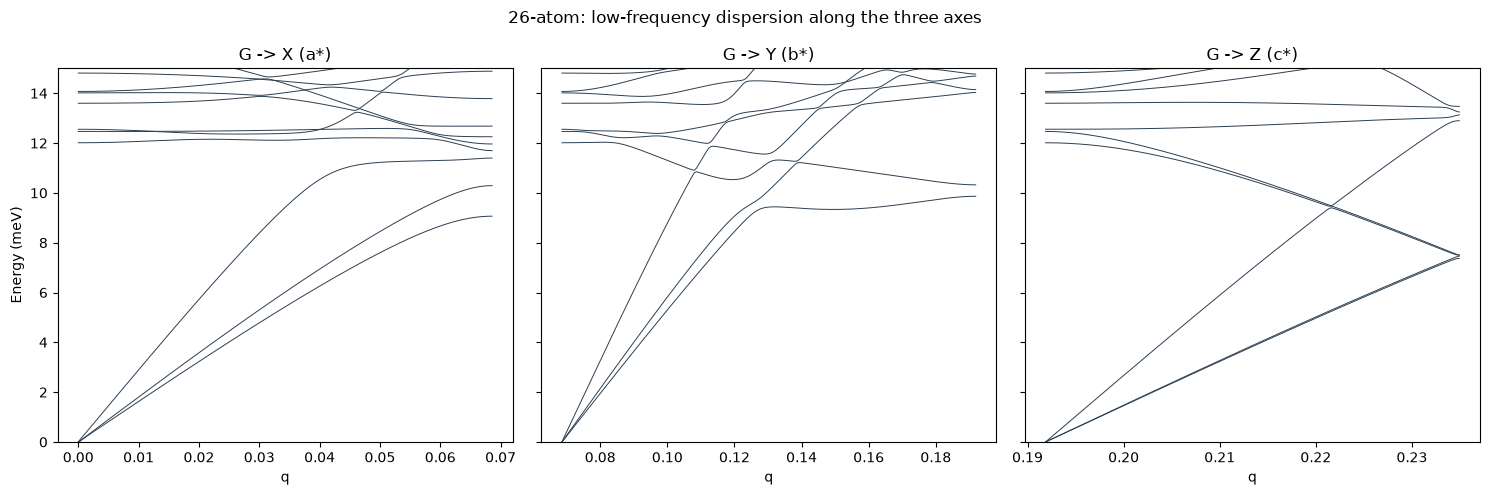

In [1]:
import phonopy, numpy as np, matplotlib.pyplot as plt
from phonopy.phonon.band_structure import get_band_qpoints_and_path_connections

THZ_TO_MEV = 4.13567

ph = phonopy.load("o2_phonon_26atom.yaml")

# Gamma to zone boundary along each reciprocal axis. I don't know offhand
# which axis of this cell is the periodic (pseudo-tenfold) one - compute all
# three and identify them from the dispersions themselves.
paths = [[[0,0,0],[0.5,0,0]], [[0,0,0],[0,0.5,0]], [[0,0,0],[0,0,0.5]]]
qpoints, connections = get_band_qpoints_and_path_connections(paths, npoints=201)
ph.run_band_structure(qpoints, path_connections=connections)
bs = ph.get_band_structure_dict()

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
labels = ["G -> X (a*)", "G -> Y (b*)", "G -> Z (c*)"]
for i, ax in enumerate(axes):
    freqs = bs["frequencies"][i] * THZ_TO_MEV
    dists = bs["distances"][i]
    ax.plot(dists, freqs, lw=0.7, color="#2c3e50")
    ax.set_title(labels[i]); ax.set_ylim(0, 15)
    ax.set_xlabel("q")
axes[0].set_ylabel("Energy (meV)")
plt.suptitle("26-atom: low-frequency dispersion along the three axes")
plt.tight_layout()
plt.savefig("o3_dispersion_26atom.png", dpi=150, bbox_inches="tight")
plt.show()

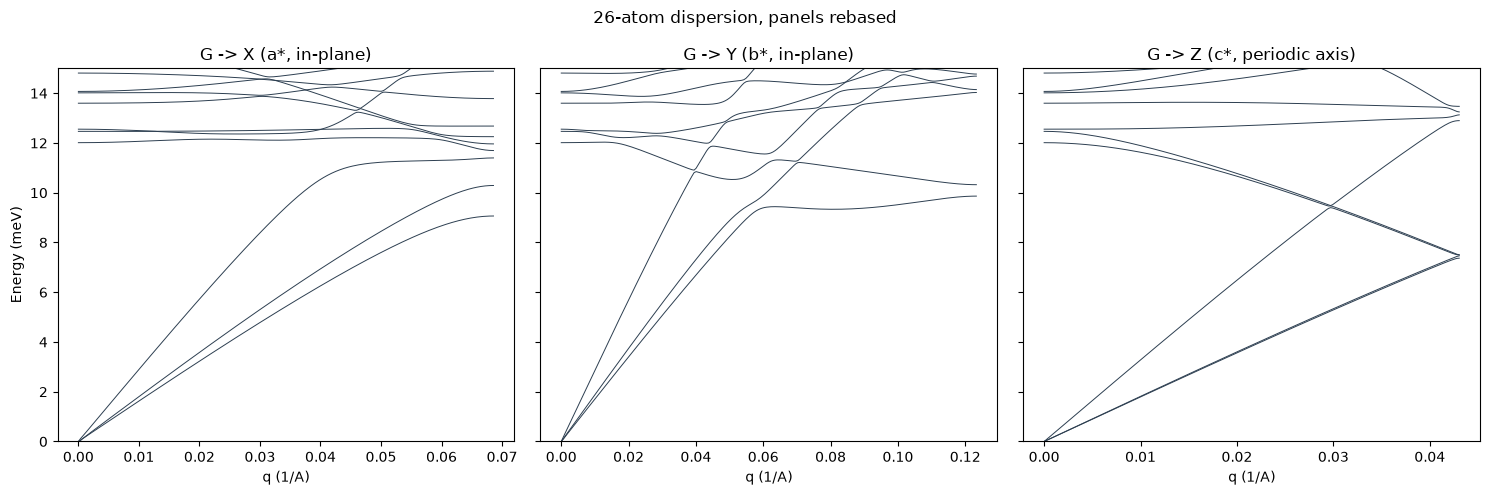

Acoustic slopes near Gamma (first 10 q-points):
  a* branch 0:   166.9 meV*A | v =  25357 m/s (no 2pi) or   4036 m/s (with 2pi)
  a* branch 1:   183.3 meV*A | v =  27847 m/s (no 2pi) or   4432 m/s (with 2pi)
  a* branch 2:   287.3 meV*A | v =  43647 m/s (no 2pi) or   6947 m/s (with 2pi)
  b* branch 0:   172.4 meV*A | v =  26190 m/s (no 2pi) or   4168 m/s (with 2pi)
  b* branch 1:   188.5 meV*A | v =  28631 m/s (no 2pi) or   4557 m/s (with 2pi)
  b* branch 2:   286.2 meV*A | v =  43483 m/s (no 2pi) or   6921 m/s (with 2pi)
  c* branch 0:   179.6 meV*A | v =  27281 m/s (no 2pi) or   4342 m/s (with 2pi)
  c* branch 1:   181.9 meV*A | v =  27629 m/s (no 2pi) or   4397 m/s (with 2pi)
  c* branch 2:   329.3 meV*A | v =  50020 m/s (no 2pi) or   7961 m/s (with 2pi)

Band energies at the a* zone boundary (meV), lowest 12:
[ 9.06 10.29 11.4  11.7  11.96 12.25 12.68 13.78 14.89 15.72 16.01 16.96]

Gaps = jumps between consecutive values above.


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
labels = ["G -> X (a*, in-plane)", "G -> Y (b*, in-plane)", "G -> Z (c*, periodic axis)"]

for i, ax in enumerate(axes):
    freqs = bs["frequencies"][i] * THZ_TO_MEV
    dists = bs["distances"][i] - bs["distances"][i][0]   # each panel from zero
    ax.plot(dists, freqs, lw=0.7, color="#2c3e50")
    ax.set_title(labels[i]); ax.set_ylim(0, 15); ax.set_xlabel("q (1/A)")
axes[0].set_ylabel("Energy (meV)")
plt.suptitle("26-atom dispersion, panels rebased")
plt.tight_layout(); plt.savefig("o3_dispersion_26atom_v2.png", dpi=150, bbox_inches="tight"); plt.show()

# acoustic slopes near Gamma -> sound velocities
print("Acoustic slopes near Gamma (first 10 q-points):")
for i, lab in enumerate(["a*", "b*", "c*"]):
    freqs = bs["frequencies"][i] * THZ_TO_MEV
    dists = bs["distances"][i] - bs["distances"][i][0]
    for b in range(3):                                   # three acoustic branches
        slope = np.polyfit(dists[1:10], freqs[1:10, b], 1)[0]   # meV * A
        # meV*A -> m/s: E=hbar*v*q with q in rad/m needs a 2pi if distances
        # exclude it. Print both conventions; the one landing near ~4000/7500
        # m/s (Chernikov) is the right one.
        v_no2pi = slope * 1e-3 * 1.602e-19 / 1.0546e-34 * 1e-10
        print(f"  {lab} branch {b}: {slope:7.1f} meV*A | "
          f"v = {v_no2pi:6.0f} m/s (no 2pi) or {v_no2pi/(2*np.pi):6.0f} m/s (with 2pi)")

# band energies at the a* zone boundary - where the gaps open
freqs_x = bs["frequencies"][0] * THZ_TO_MEV
edge = freqs_x[-1]                                       # last q-point
print("\nBand energies at the a* zone boundary (meV), lowest 12:")
print(np.round(np.sort(edge)[:12], 2))
print("\nGaps = jumps between consecutive values above.")

/var/folders/3p/symqw42d0dv_htgds0njggmh0000gn/T/ipykernel_1555/1941010657.py:11: DeprecationWarning: get_band_structure_dict() is deprecated. Use the band_structure property to access the BandStructure result object; its qpoints, distances, frequencies, eigenvectors, and group_velocities attributes replace the dict keys.
  bs = ph.get_band_structure_dict()


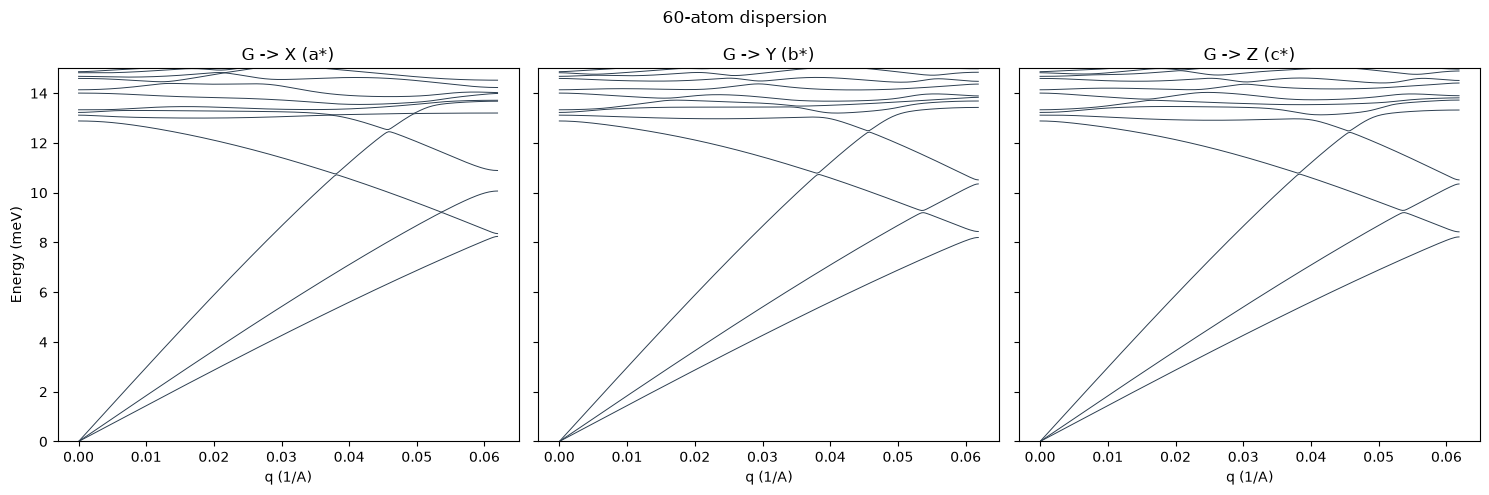

60-ATOM DISPERSION NUMBERS

Acoustic slopes near Gamma -> sound velocities (with-2pi convention):
  a* branch 0:   3494 m/s
  a* branch 1:   4466 m/s
  a* branch 2:   7225 m/s
  b* branch 0:   3496 m/s
  b* branch 1:   4448 m/s
  b* branch 2:   7220 m/s
  c* branch 0:   3497 m/s
  c* branch 1:   4448 m/s
  c* branch 2:   7217 m/s

Zone-boundary energies along a* (lowest 14, meV):
    8.24   8.36  10.07  10.89  13.20  13.68  13.72  13.99  14.03  14.23  14.52  15.04  15.76  16.09
  jumps:  0.11  1.71  0.83  2.31  0.47  0.04  0.27  0.04  0.20  0.29  0.52  0.72  0.33
  gaps > 0.5 meV:
    8.36 -> 10.07  (width 1.71)
    10.07 -> 10.89  (width 0.83)
    10.89 -> 13.20  (width 2.31)
    14.52 -> 15.04  (width 0.52)
    15.04 -> 15.76  (width 0.72)

Zone-boundary energies along b* (lowest 14, meV):
    8.20   8.44  10.35  10.52  13.43  13.69  13.84  13.89  14.37  14.48  14.84  14.98  15.78  15.80
  jumps:  0.24  1.91  0.16  2.91  0.26  0.15  0.06  0.48  0.11  0.36  0.14  0.80  0.02
  gaps > 0

In [3]:
import phonopy, numpy as np, matplotlib.pyplot as plt
from phonopy.phonon.band_structure import get_band_qpoints_and_path_connections

THZ_TO_MEV = 4.13567

ph = phonopy.load("o2_phonon_60atom.yaml")

paths = [[[0,0,0],[0.5,0,0]], [[0,0,0],[0,0.5,0]], [[0,0,0],[0,0,0.5]]]
qpoints, connections = get_band_qpoints_and_path_connections(paths, npoints=201)
ph.run_band_structure(qpoints, path_connections=connections)
bs = ph.get_band_structure_dict()

# ---- figure (saved, no need to show me) ----
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
labels = ["G -> X (a*)", "G -> Y (b*)", "G -> Z (c*)"]
for i, ax in enumerate(axes):
    freqs = bs["frequencies"][i] * THZ_TO_MEV
    dists = bs["distances"][i] - bs["distances"][i][0]
    ax.plot(dists, freqs, lw=0.7, color="#2c3e50")
    ax.set_title(labels[i]); ax.set_ylim(0, 15); ax.set_xlabel("q (1/A)")
axes[0].set_ylabel("Energy (meV)")
plt.suptitle("60-atom dispersion")
plt.tight_layout(); plt.savefig("o3_dispersion_60atom.png", dpi=150, bbox_inches="tight"); plt.show()

# ---- NUMBERS ----
print("=" * 60)
print("60-ATOM DISPERSION NUMBERS")
print("=" * 60)

print("\nAcoustic slopes near Gamma -> sound velocities (with-2pi convention):")
for i, lab in enumerate(["a*", "b*", "c*"]):
    freqs = bs["frequencies"][i] * THZ_TO_MEV
    dists = bs["distances"][i] - bs["distances"][i][0]
    for b in range(3):
        slope = np.polyfit(dists[1:10], freqs[1:10, b], 1)[0]
        v = slope * 1e-3 * 1.602e-19 / 1.0546e-34 * 1e-10 / (2*np.pi)
        print(f"  {lab} branch {b}: {v:6.0f} m/s")

for i, lab in enumerate(["a*", "b*", "c*"]):
    freqs = bs["frequencies"][i] * THZ_TO_MEV
    edge = np.sort(freqs[-1])[:14]
    jumps = np.diff(edge)
    print(f"\nZone-boundary energies along {lab} (lowest 14, meV):")
    print("  " + " ".join(f"{e:6.2f}" for e in edge))
    print("  jumps: " + " ".join(f"{j:5.2f}" for j in jumps))
    big = [(edge[k], edge[k+1], jumps[k]) for k in range(len(jumps)) if jumps[k] > 0.5]
    if big:
        print("  gaps > 0.5 meV:")
        for lo, hi, w in big:
            print(f"    {lo:.2f} -> {hi:.2f}  (width {w:.2f})")

In [4]:
TAU = (1 + 5**0.5) / 2

print("Predicted upward ladder from Matsuura's 2.15 meV rung:")
ladder = [2.15 * TAU**n for n in range(1, 6)]
print("  " + " ".join(f"{e:.2f}" for e in ladder), "meV\n")

for i, lab in enumerate(["a*", "b*", "c*"]):
    freqs = bs["frequencies"][i] * THZ_TO_MEV
    edge = np.sort(freqs[-1])[:40]              # go much further up
    jumps = np.diff(edge)
    gaps = [(edge[k], edge[k+1]) for k in range(len(jumps)) if jumps[k] > 0.5]
    centres = [(lo+hi)/2 for lo, hi in gaps]
    widths  = [hi-lo for lo, hi in gaps]

    print(f"--- {lab} ---")
    print("gap centres (meV): " + " ".join(f"{c:6.2f}" for c in centres))
    print("gap widths  (meV): " + " ".join(f"{w:6.2f}" for w in widths))
    if len(centres) > 1:
        ratios = [centres[k+1]/centres[k] for k in range(len(centres)-1)]
        print("successive centre ratios: " + " ".join(f"{r:5.3f}" for r in ratios)
              + f"   (tau = {TAU:.3f})")
    # distance of each centre from the nearest predicted rung
    print("vs predicted ladder:")
    for c in centres:
        nearest = min(ladder, key=lambda x: abs(x - c))
        print(f"  centre {c:6.2f}  nearest rung {nearest:6.2f}  off by {c-nearest:+5.2f} meV")
    print()

Predicted upward ladder from Matsuura's 2.15 meV rung:
  3.48 5.63 9.11 14.74 23.84 meV

--- a* ---
gap centres (meV):   9.21  10.48  12.05  14.78  15.40
gap widths  (meV):   1.71   0.83   2.31   0.52   0.72
successive centre ratios: 1.138 1.150 1.227 1.042   (tau = 1.618)
vs predicted ladder:
  centre   9.21  nearest rung   9.11  off by +0.11 meV
  centre  10.48  nearest rung   9.11  off by +1.37 meV
  centre  12.05  nearest rung  14.74  off by -2.69 meV
  centre  14.78  nearest rung  14.74  off by +0.05 meV
  centre  15.40  nearest rung  14.74  off by +0.67 meV

--- b* ---
gap centres (meV):   9.40  11.97  15.38
gap widths  (meV):   1.91   2.91   0.80
successive centre ratios: 1.274 1.285   (tau = 1.618)
vs predicted ladder:
  centre   9.40  nearest rung   9.11  off by +0.29 meV
  centre  11.97  nearest rung  14.74  off by -2.76 meV
  centre  15.38  nearest rung  14.74  off by +0.64 meV

--- c* ---
gap centres (meV):   9.39  11.92  14.15  15.34
gap widths  (meV):   1.92   2.81   0.51